In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torchvision import models
from torch.utils.data import Dataset , DataLoader
import pennylane as qml
import numpy as np
import os
import yaml
import pandas as pd
from sklearn.preprocessing import LabelEncoder
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split 
from PIL import Image
from tqdm.notebook import tqdm
from typing import Dict, List, Tuple
import timm
from timm.loss import LabelSmoothingCrossEntropy

print(torch.__version__)
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
print(device)

2.12.1+cpu
cpu


In [2]:
path = r"Remote Sensing Data.v2i.yolov8" 

with open(os.path.join(path, "data.yaml"), "r") as f:
    config = yaml.safe_load(f)
class_names = config['names']

data = {"imagepath": [], "labels": [], "split": []}
category = ["train", "valid", "test"]

for folder in category:
    img_dir = os.path.join(path, folder, "images")
    lbl_dir = os.path.join(path, folder, "labels")
    if not os.path.exists(img_dir):
        continue
    filelist = os.listdir(img_dir)
    for file in filelist:
        fpath = os.path.join(img_dir, file)
        lbl_path = os.path.join(lbl_dir, os.path.splitext(file)[0] + ".txt")
        label = "unknown"
        if os.path.exists(lbl_path):
            with open(lbl_path) as f:
                line = f.readline().strip()
                if line:
                    class_id = int(line.split()[0])
                    label = class_names[class_id]
        data["imagepath"].append(fpath)
        data["labels"].append(label)
        data["split"].append(folder)

df = pd.DataFrame(data)
lb = LabelEncoder()
df['encoded_labels'] = lb.fit_transform(df['labels'])

print(df.head())
print(df.labels.value_counts())

                                           imagepath    labels  split  \
0  Remote Sensing Data.v2i.yolov8\train\images\00...     Beach  train   
1  Remote Sensing Data.v2i.yolov8\train\images\00...   Parking  train   
2  Remote Sensing Data.v2i.yolov8\train\images\00...  Mountain  train   
3  Remote Sensing Data.v2i.yolov8\train\images\00...    Desert  train   
4  Remote Sensing Data.v2i.yolov8\train\images\00...    Forest  train   

   encoded_labels  
0               2  
1              10  
2               9  
3               4  
4               5  
labels
City           168
Grassland       92
Desert          89
Forest          80
Mountain        79
Agriculture     79
Parking         69
Port            68
Beach           63
Airport         63
Highway         51
Lake            39
Railway         35
River           25
Name: count, dtype: int64


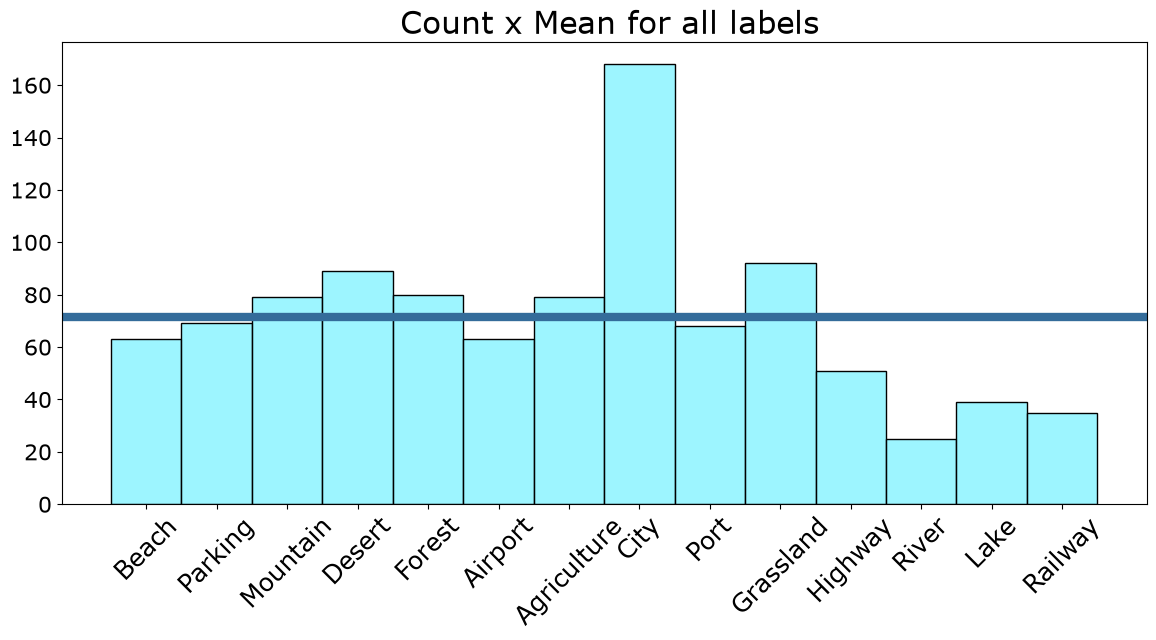

In [3]:
ax = sns.histplot(data=df, x="labels", color="#7df2ff")
ax.figure.set_size_inches(14, 6)
plt.axhline(y=df.groupby("labels").count().mean().mean(), lw=6, color="#346c9a")
plt.xticks(rotation=45, font="Verdana", fontsize=18)
plt.yticks(font="Verdana", fontsize=16)
ax.set_ylabel("")
ax.set_xlabel("")
ax.set_title(" Count x Mean for all labels", font="Verdana", fontsize=22)

plt.show()

In [4]:
train_df, temp_df = train_test_split(df,  train_size= 0.70 , shuffle=True, random_state=124, stratify = df.labels)
valid_df , test_df = train_test_split(temp_df ,  train_size= 0.70 , shuffle=True, random_state=124)
train_df = train_df.reset_index(drop=True)
valid_df = valid_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

print("----------Train-------------")
print(train_df[["imagepath", "labels"]].head(5))
print(train_df.shape)
print("--------Validation----------")
print(valid_df[["imagepath", "labels"]].head(5))
print(valid_df.shape)
print("----------Test--------------")
print(test_df[["imagepath", "labels"]].head(5))
print(test_df.shape)

----------Train-------------
                                           imagepath     labels
0  Remote Sensing Data.v2i.yolov8\train\images\22...    Parking
1  Remote Sensing Data.v2i.yolov8\test\images\094...       Port
2  Remote Sensing Data.v2i.yolov8\train\images\26...     Forest
3  Remote Sensing Data.v2i.yolov8\valid\images\37...   Mountain
4  Remote Sensing Data.v2i.yolov8\train\images\38...  Grassland
(700, 4)
--------Validation----------
                                           imagepath     labels
0  Remote Sensing Data.v2i.yolov8\train\images\72...    Airport
1  Remote Sensing Data.v2i.yolov8\train\images\72...       Lake
2  Remote Sensing Data.v2i.yolov8\valid\images\11...  Grassland
3  Remote Sensing Data.v2i.yolov8\train\images\00...     Desert
4  Remote Sensing Data.v2i.yolov8\train\images\45...       Port
(210, 4)
----------Test--------------
                                           imagepath   labels
0  Remote Sensing Data.v2i.yolov8\train\images\60...    River
1  

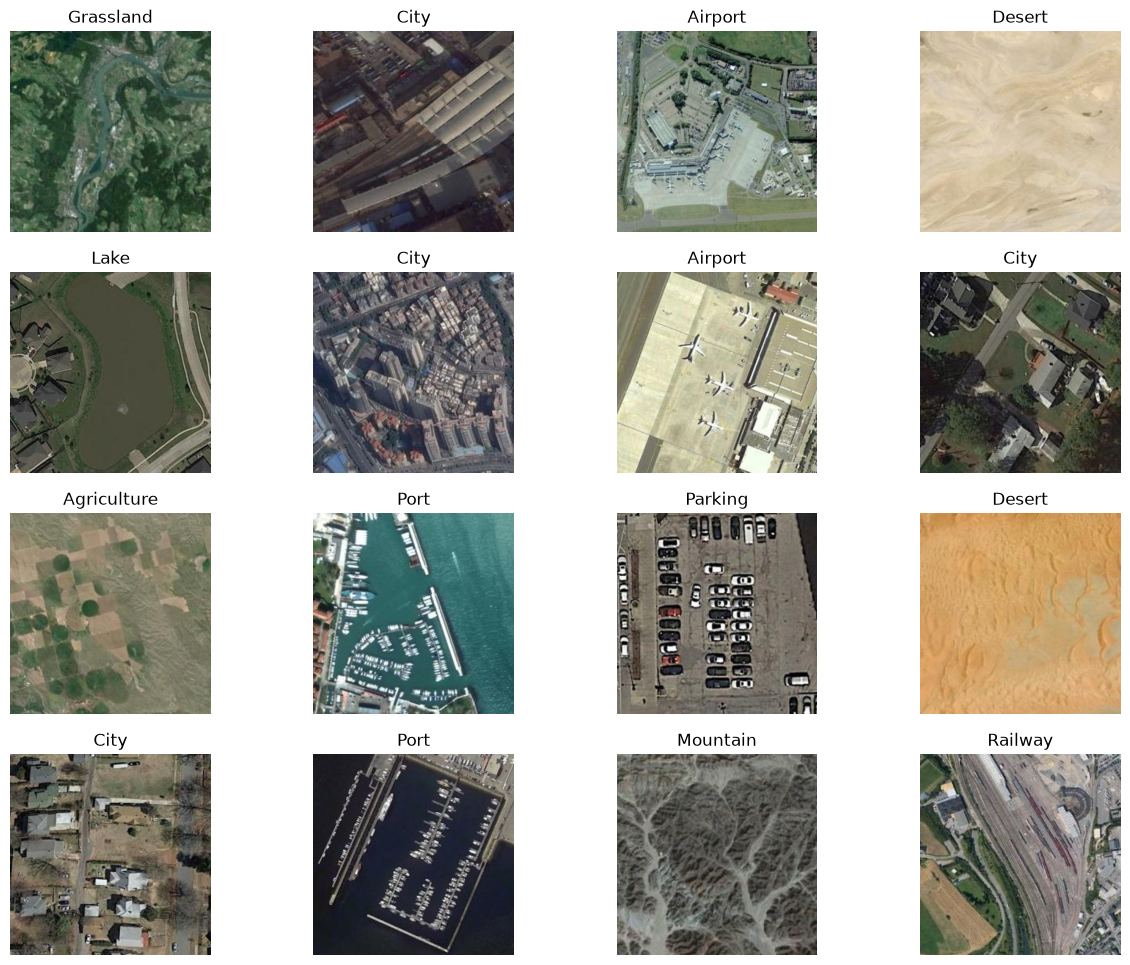

In [5]:
plt.figure(figsize=(15,12))
for i, row in test_df.sample(n=16).reset_index().iterrows():
    plt.subplot(4,4,i+1)
    image_path = row['imagepath']
    image = Image.open(image_path)
    plt.imshow(image)
    plt.title(row["labels"])
    plt.axis('off')
plt.show()

In [6]:
train_transforms = transforms.Compose([
    #transforms.RandomResizedCrop(size=256, scale=(0.8, 1.0)),
    transforms.Resize((128, 128)),
    transforms.RandomRotation(degrees=15),
    #transforms.RandomVerticalFlip(p=0.5),
    transforms.RandomHorizontalFlip(),
    transforms.CenterCrop(size=128),
    transforms.ToTensor(),
    #transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

test_transforms = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
    #transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

In [7]:
#Load & View Random Sample Image
def load(imagepath, as_tensor=True):
    # Read and decode an image file to a uint8 tensor
    image = Image.open(imagepath).convert('RGB')
    
    if as_tensor:
        converter = transforms.ToTensor()
        return converter(image)
    else:
        return image


def view_sample(image, label, color_map='rgb', fig_size=(8, 10)):
    plt.figure(figsize=fig_size)
    
    if color_map=='rgb':
        plt.imshow(image)
    else:
        plt.imshow(image, cmap=color_map)
    
    plt.title(f'Label: {label}', fontsize=16)
    return

In [8]:
# Select random sample from df
import random
idx = random.sample(df.index.to_list(), 1)[0]

# Load the random sample and label
aug_image = load(df.imagepath[idx], as_tensor=False)

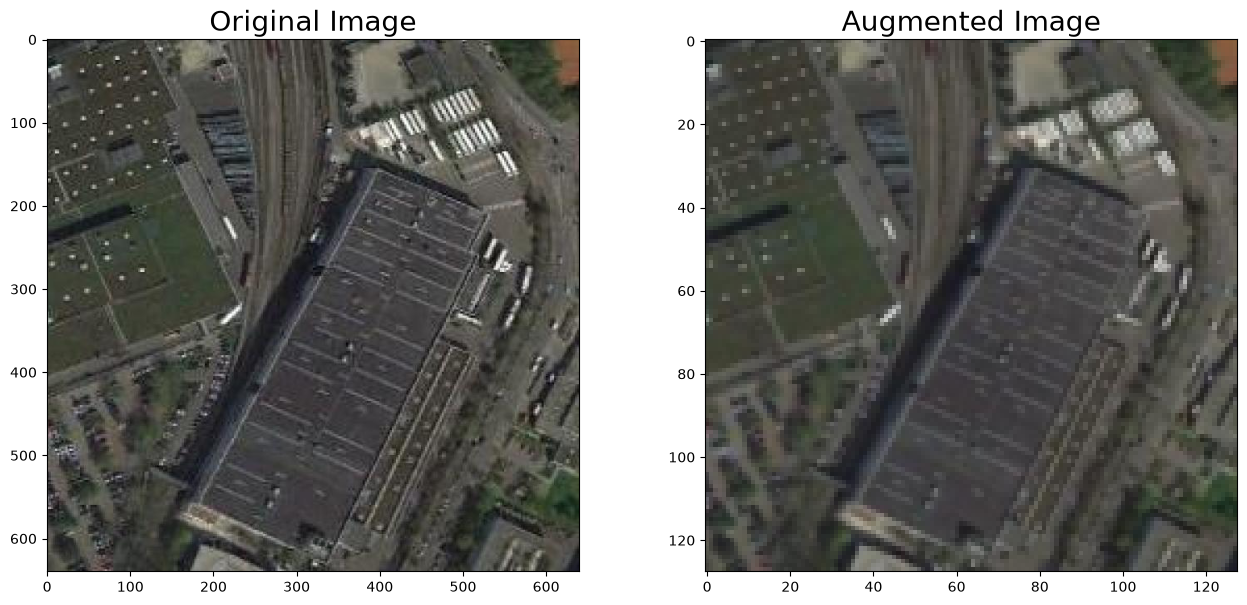

In [9]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 10))

# Set the spacing between subplots
fig.tight_layout(pad=6.0)

# View Original Image
ax1.set_title('Original Image', fontsize=20)
ax1.imshow(aug_image);

# View Augmented Image
ax2.set_title('Augmented Image', fontsize=20)
ax2.imshow(train_transforms(aug_image).permute(1, 2, 0));

In [10]:
class ArSL_Dataset(Dataset):
    def __init__(self, df:pd.DataFrame, transform=None) -> None:
        super().__init__()
        
        self.paths = df['imagepath'].to_list()
        self.labels = df['labels'].to_list()
        self.transform = transform
        
        self.classes = sorted(list(df['labels'].unique()))
        self.class_to_idx = {cls_name: _ for _, cls_name in enumerate(self.classes)}
        
    def load_image(self, index:int) -> Image.Image:
        image_path = self.paths[index]
        return Image.open(image_path).convert('RGB')  
        
    def __len__(self) -> int:
        return self.paths.__len__()
    
    def __getitem__(self, index:int) -> Tuple[torch.Tensor, int]:
        image = self.load_image(index)
        class_name = self.labels[index]
        class_idx = self.class_to_idx[class_name]

        # Transform if necessary
        if self.transform:
            return self.transform(image), class_idx
        else:
            return image, class_idx

In [11]:
# Build train dataset
train_ds = ArSL_Dataset(train_df, transform=train_transforms)

# Build validation dataset
#valid_ds = ArSL_Dataset(valid_df, transform=test_transforms)

# Build test dataset
test_ds = ArSL_Dataset(test_df, transform=test_transforms)

In [12]:
BATCH_SIZE = (
        64 if torch.cuda.device_count() < 2 
        else (64 * torch.cuda.device_count())
    )
train_dataloader = DataLoader(train_ds, batch_size = BATCH_SIZE, shuffle=True)
#valid_dataloader = DataLoader(valid_ds, batch_size = BATCH_SIZE, shuffle= False)
test_dataloader = DataLoader(test_ds, batch_size= BATCH_SIZE , shuffle=False)

print(">> Number of Train Data : {} -- Batch Size : {} -- Number of Batch : {} ".format(len(train_dataloader.dataset) , BATCH_SIZE , len(train_dataloader)))
#print(">> Number of Valid Data : {} -- Batch Size : {} -- Number of Batch : {} ".format(len(valid_dataloader.dataset) , BATCH_SIZE , len(valid_dataloader)))
print(">> Number of  Test Data : {} -- Batch Size : {} -- Number of Batch : {} ".format(len(test_dataloader.dataset) , BATCH_SIZE , len(test_dataloader)))
onebatch = iter(train_dataloader)
train_features, train_labels = next(onebatch)
print("----------Batch Shape--------")
print(f"Feature batch shape: {train_features.size()}")
print("----------Labels Shape--------")
print(f"Labels batch shape: {train_labels.size()}")

>> Number of Train Data : 700 -- Batch Size : 64 -- Number of Batch : 11 
>> Number of  Test Data : 90 -- Batch Size : 64 -- Number of Batch : 2 
----------Batch Shape--------
Feature batch shape: torch.Size([64, 3, 128, 128])
----------Labels Shape--------
Labels batch shape: torch.Size([64])


In [13]:
class HybridQuantumClassicalNN(nn.Module):
    def __init__(self, num_classes=14):
        super(HybridQuantumClassicalNN, self).__init__()

        
        self.cnn = nn.Sequential(
            # Block 1: 3x128x128 → 32x64x64
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),

            # Block 2: 32x64x64 → 64x32x32
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),

            # Block 3: 64x32x32 → 128x16x16
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Flatten()  # 128x16x16 = 32768
        )

        
        self.quantum_layer = nn.Linear(32768, 128)

        # Classical classifier
        self.classical_layer = nn.Sequential(
            nn.ReLU(),
            nn.Dropout(0.3),      
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, num_classes)
        )

    def forward(self, x):
        x = self.cnn(x)               
        x = self.quantum_layer(x)    
        x = self.classical_layer(x)   
        return x

In [14]:
model = HybridQuantumClassicalNN(num_classes=14).to(device)

In [15]:
# Define Loss Function
loss_fn = LabelSmoothingCrossEntropy()

# Define Optimizer
optimizer = optim.Adam(model.parameters(),lr= 0.001)

In [16]:
def execute_epoch(
    model:torch.nn.Module,
    dataloader:torch.utils.data.DataLoader,
    optimizer:torch.optim.Optimizer,
    loss_fn:torch.nn.Module,
    device:torch.device) -> Tuple[float, float]:
    
    # Set model into training mode
    model.train()
    
    # Initialize train loss & accuracy
    train_loss, train_acc = 0, 0
    
    # Execute training loop over train dataloader
    for batch, (X, y) in enumerate(tqdm(dataloader)):
        # Load data onto target device
        X, y = X.to(device), y.to(device)
        
        # Feed-forward and compute metrics
        y_pred = model(X)
        loss = loss_fn(y_pred, y)
        train_loss += loss.item() 
        
        # Reset Gradients & Backpropagate Loss
        optimizer.zero_grad()
        loss.backward()
        
        # Update Model Gradients
        optimizer.step()
        
        # Compute Batch Metrics
        predicted_class = torch.argmax(
            torch.softmax(y_pred, dim=1), dim=1)
        train_acc += (predicted_class == y).sum().item() / len(y_pred)
        
    # Compute Step Metrics
    train_loss = train_loss / len(dataloader)
    train_acc = train_acc / len(dataloader)
    
    return train_loss, train_acc

In [17]:
def evaluate(
    model:torch.nn.Module,
    dataloader:torch.utils.data.DataLoader,
    loss_fn:torch.nn.Module,
    device:torch.device) -> Tuple[float, float]:
    
    # Set model into eval mode
    model.eval()
    
    # Initialize eval loss & accuracy
    eval_loss, eval_acc = 0, 0
    
    # Active inferene context manager
    with torch.inference_mode():
        # Execute eval loop over dataloader
        for batch, (X, y) in enumerate(dataloader):
            # Load data onto target device
            X, y = X.to(device), y.to(device)

            # Feed-forward and compute metrics
            y_pred = model(X)
            loss = loss_fn(y_pred, y)
            eval_loss += loss.item() 

            # Compute Batch Metrics
            predicted_class = torch.argmax(
                torch.softmax(y_pred, dim=1), dim=1)
            eval_acc += (predicted_class == y).sum().item() / len(y_pred)
        
    # Compute Step Metrics
    eval_loss = eval_loss / len(dataloader)
    eval_acc = eval_acc / len(dataloader)
    
    return eval_loss, eval_acc

In [18]:
def train(
    model:torch.nn.Module,
    train_dataloader:torch.utils.data.DataLoader,
    eval_dataloader:torch.utils.data.DataLoader,
    optimizer:torch.optim.Optimizer,
    loss_fn:torch.nn.Module,
    epochs:int,
    device:torch.device) -> Dict[str, List]:
    
    # Initialize training session
    session = {
        'loss'          : [],
        'accuracy'      : [],
        'eval_loss'     : [],
        'eval_accuracy': []
    }
    
    # Training loop
    for epoch in tqdm(range(epochs)):
        # Execute Epoch
        print(f'\nEpoch {epoch + 1}/{epochs}')
        train_loss, train_acc = execute_epoch(
            model, 
            train_dataloader, 
            optimizer, 
            loss_fn, 
            device
        )
        
        # Evaluate Model
        eval_loss, eval_acc = evaluate(
            model, 
            eval_dataloader,
            loss_fn, 
            device
        )
        
        # Log Epoch Metrics
        print(f'loss: {train_loss:.4f} - acc: {train_acc:.4f} - eval_loss: {eval_loss:.4f} - eval_acc: {eval_acc:.4f}')
        
        # Record Epoch Metrics
        session['loss'].append(train_loss)
        session['accuracy'].append(train_acc)
        session['eval_loss'].append(eval_loss)
        session['eval_accuracy'].append(eval_acc)
        
    # Return Session Metrics
    return session

In [19]:
# Train the model 
print(f'Train on {len(train_df)} samples, validate on {len(test_df)} samples.')
print('----------------------------------')

session_config = {
    'model'               : model,
    'train_dataloader'    : train_dataloader,
    'eval_dataloader'     : test_dataloader,
    'optimizer'           : optimizer,
    'loss_fn'             : loss_fn,
    'epochs'              : 20,
    'device'              : device
}

session_history = train(**session_config)

Train on 700 samples, validate on 90 samples.
----------------------------------


  0%|          | 0/20 [00:00<?, ?it/s]


Epoch 1/20


  0%|          | 0/11 [00:00<?, ?it/s]

loss: 3.5100 - acc: 0.1476 - eval_loss: 2.6409 - eval_acc: 0.1160

Epoch 2/20


...

loss: 1.7572 - acc: 0.5098 - eval_loss: 1.6623 - eval_acc: 0.5805

Epoch 19/20


  0%|          | 0/11 [00:00<?, ?it/s]

loss: 1.6920 - acc: 0.5264 - eval_loss: 1.6664 - eval_acc: 0.5775

Epoch 20/20


  0%|          | 0/11 [00:00<?, ?it/s]

loss: 1.6748 - acc: 0.5111 - eval_loss: 1.7382 - eval_acc: 0.5577
